In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/03. 머신러닝 수업 자료/7. 텍스트 마이닝, 추천 알고리즘

/content/drive/MyDrive/03. 머신러닝 수업 자료/7. 텍스트 마이닝, 추천 알고리즘


![img](https://mblogthumb-phinf.pstatic.net/MjAyMDAxMTVfMjI3/MDAxNTc5MDkwNzE3ODQ3.ebgR3CuKR3M_b-JHgFUZcYr4MObO6NSCEOLtbgPaiR0g.64dG3M8jvL3kdzXMZlYKAT4urxPM0grzRML2RDnyeNkg.PNG.dkgoggog21/XCV.png?type=w2)

- 위 사진과 같이, 유튜브의 알수없는 알고리즘이 추천해주는 동영상을 계속 본 적이 있을거임
- 유튜브 뿐만 아니라 넷플릭스, 왓챠 이런 사이트들은 꼭 유저의 취향에 맞는 것을 추천해줌

> `조금이라도 오래 자기 사이트에 고객을 머무르게 하기위한 전략`
> - 실제로 많은 전자상거래 업체(유튜브, 아마존, 넷플릭스, 쿠팡 등)가 추천 엔진의 고도화에 큰 비용과 노력을 들임
> - 매출을 큰 폭으로 증가시킴과 함께 사용자의 쇼핑 즐거움 또한 배가됨

→ 이로 인해, 온라인 스토어에서의 추천 시스템은 필수 구성 요소가 됨

# 추천 시스템이란?

> 사용자(USER)에게 관련된 아이템(item)을 추천해주는 것

```
추천 ex)
A와 B가 넷플릭스에 가입했다고 가정

A와 B의 선호도
- A : 한국 드라마/영화, 로맨스물
- B : 미국 드라마/영화, 액션물

A에게는 `사이코지만 괜찮아`를 추천하고,
B에게는 `워킹데드`를 추천해주면 괜찮을 것 같음
```

> 추천 시스템 사례
- e-commerce: 쿠팡과 같은 온라인 쇼핑몰에서 고객의 구매 이력과 검색 이력을 바탕으로 제품을 추천
- 스트리밍 서비스: 넷플릭스, 유튜브, 스포티파이 등에서 사용자의 시청/청취 이력을 바탕으로 영화, 동영상, 음악을 추천
- 뉴스 포털: 사용자가 관심을 가질 만한 뉴스 기사를 추천 등

# 추천 시스템의 종류

<img src = "https://oopy.lazyrockets.com/api/v2/notion/image?src=https%3A%2F%2Fprod-files-secure.s3.us-west-2.amazonaws.com%2Fa21ec021-5399-43b4-839c-6d528586f469%2F413979b5-e77a-4847-b4b2-39e1e48b2cbd%2FUntitled.png&blockId=0761ae34-9a21-4e71-a541-a287f07c7310"/>

1. 콘텐츠 기반 필터링 (Contents-Based Filtering)
2. 협업(협력) 필터링 (Collaborative Filtering)
    - 기억 기반 (Memorial Based) `또는 최근접 이웃 (Nearest Neighbor) 기반`
        - 사용자 기반 (User Based)
        - 아이템 기반 (Item Based)
    - 모델 기반 협업 필터링
        - 잠재 요인 (Latent Factor) 협업 필터링 → 행렬 인수분해
        - ML & DL 포함
3. Hybrid 방식

```python
- 추천 시스템의 초창기에는 "콘텐츠 기반"/"최근접 이웃 기반 협업" 필터링이 주로 사용되어 왔음
- 그러나, "넷플릭스 추천 시스템 경연 대회"에서 "잠재 요인 협업 필터링" 방식이 우승하면서, 많은 추천 시스템의 대중화가 됨
- 허나, 서비스 하는 아이템 특성에 따라 콘텐츠 기반이나 최근접 이웃 기반을 유지하는 사이트도 존재함
- 요즘에는 "개인화 특성을 좀 더 강화"하기 위한 "하이브리드 형식(콘텐츠와 협업을 적절히 결합)"이나 "딥러닝 기반"이 많이 활용됨
```

# 콘텐츠 기반 필터링 (Contents-Based Filtering)

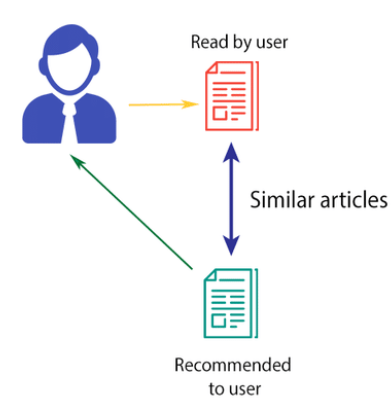

- 말 그대로 비슷한 item의 특성을 기반으로 추천해주는 것
- 유사도 기반으로 쉽게 구현 가능

In [ ]:
import pandas as pd

In [ ]:
# 데이터 로드
df = pd.read_csv("./data/lyrics_by_year_1964_2023.csv")

# 1964년부터 2023년 사이의 MELON 연도별 TOP 100 노래

In [ ]:
# 데이터 확인
display(df.head())
df.info()

# lyric 결측치 확인

,id,year,title,singer,lyric,x_rated
0,30072384,1964,워싱턴광장,정 시스터즈,NaN,False
1,8150699,1964,황혼의 에레지,최양숙,NaN,False
2,5758967,1964,물새우는 해변,권혜경,고요한 밤하늘에 별이 잠들고\n밀리는 파도소리 나혼자 들으며\n외로히 홀로 날으는 ...,False
3,4083218,1964,내일또 만납시다,금호동,하루의 일을 끝내고 돌아가는\n거리엔 사람의 물결\n하늘엔 별이 하나 둘 반짝이면\...,False
4,3622464,1964,밀짚모자 목장아가씨,박재란,시원한 밀짚모자\n포플라 그늘에\n양떼를 몰고가는\n목장의 아가씨\n연분홍 빛 입술...,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4666 entries, 0 to 4665
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       4666 non-null   int64 
 1   year     4666 non-null   int64 
 2   title    4666 non-null   object
 3   singer   4666 non-null   object
 4   lyric    4458 non-null   object
 5   x_rated  4666 non-null   bool  
dtypes: bool(1), int64(2), object(3)
memory usage: 187.0+ KB


| 컬럼명 | 설명 |
| --- | --- |
| id | 각 노래의 고유 식별자 |
| year | 노래가 발표된 연도 |
| title | 노래 제목 |
| singer | 노래 가수 이름 |
| lyric | 노래 가사 |
| x_rated | X-rated 여부 |

# 가사(lyric)를 활용한 유사도 기반으로 추천 시스템 만들어보기

## 1. 전처리
- 1.1 결측치 제거
- 1.2 특수문자 제거

- 1.1 결측치 제거

In [ ]:
# 결측치 행 제거 & 인덱스 재설정
df = df.dropna().reset_index(drop = True) # 제거한 인덱스를 컬럼으로 추가할지 여부
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4458 entries, 0 to 4457
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       4458 non-null   int64 
 1   year     4458 non-null   int64 
 2   title    4458 non-null   object
 3   singer   4458 non-null   object
 4   lyric    4458 non-null   object
 5   x_rated  4458 non-null   bool  
dtypes: bool(1), int64(2), object(3)
memory usage: 178.6+ KB


- 1.2 특수문자 제거 → re 활용

In [ ]:
import re

In [ ]:
# r"" : 원시(raw)문자열, \를 하나만 사용 가능하게끔 만듬!
pattern = r'[^a-zA-Z0-9가-힣\s\.\?\!]'

# 알파벳, 숫자, 한글문자, 공백을 제외한 패턴
# 리뷰가 길어지는 경우, 문장 구분을 위해 공백(\s), .?! 보존
# "\s"는 공백 문자를 의미하며, 여기에는 줄바꿈(\n)도 포함됨
# ^ : not

In [ ]:
# 가사 클리닝 후 append
cleaned_lyrics = [ re.sub(pattern, "", lyric) for lyric in df["lyric"] ]

In [ ]:
cleaned_lyrics[:5]

['고요한 밤하늘에 별이 잠들고\n밀리는 파도소리 나혼자 들으며\n외로히 홀로 날으는 물새의 울음소리\n쓸쓸한 내 마음 속에 슬픔을 주네\n고요한 밤하늘에 별이 잠들고\n밀리는 파도소리 나혼자 들으며\n외로히 홀로 날으는 물새의 울음소리\n쓸쓸한 내 마음 속에 슬픔을 주네\n',
 '하루의 일을 끝내고 돌아가는\n거리엔 사람의 물결\n하늘엔 별이 하나 둘 반짝이면\n가로등 하나 둘 꽃 피네\n허공을 스치는 바람은 차고\n흐뭇한 마음은 애드베룬\n가벼운 발길 헤어질 때 인사는\n내일 또 다시 만납시다\n하루의 일을 끝내고 돌아가는\n거리엔 사람의 물결\n하늘엔 별이 하나 둘 반짝이면\n가로등 하나 둘 꽃 피네\n허공을 스치는 바람은 차고\n흐뭇한 마음은 애드베룬\n가벼운 발길 헤어질 때 인사는\n내일 또 다시 만납시다\n내일 또 다시 만납시다\n',
 '시원한 밀짚모자\n포플라 그늘에\n양떼를 몰고가는\n목장의 아가씨\n연분홍 빛 입술에는\n살며시 웃음 띄우고\n넓다란 푸른 목장\n하늘에 구름가네\n라라라 라라라라라\n라라라라 라라라라\n라라라 라라라라라\n라라라라 라라라라\n연분홍 빛 입술에는\n살며시 웃음 띄우고\n넓다란 푸른 목장\n하늘에 구름가네\n구름가네 음음음음\n',
 '비가 나리네 비가 나리네\n돌아선 이가슴에\n그님은 어데 그어느곳에\n이마음 벗사려 떨어져가도\n이마음 몹쓸건 미련때문에\n아 몸부림치며 님을 불렀네\n이마음 모질게 헤어져가고\n이마음 몹쓸건 미련때문에\n아 목놓아 울며 님을 불렀네\n',
 '잊지 못할 빗속의 여인\n지금은 어데 있나\n\n노오란 레인코트에\n검은 눈동자 잊지 못하네\n\n다정하게 미소지며\n검은 우산을 받쳐주네\n나리는 빗방울 바라보며\n말없이 말없이 걸었네\n\n잊지 못할 빗속의 여인\n그 여인을 잊지 못하네\n\n다정하게 미소지며\n검은 우산을 받쳐주네\n나리는 빗방울 바라보며\n말없이 말없이 걸었네\n\n잊지 못할 빗 속의 여인\n그 여인을 잊지 못하네\n\n오 잊지 못할 빗 속의 여인\n그 여인을 잊지 못

In [ ]:
df["cleaned_lyric"] = cleaned_lyrics
df.head(3)

,id,year,title,singer,lyric,x_rated,cleaned_lyric
0,5758967,1964,물새우는 해변,권혜경,고요한 밤하늘에 별이 잠들고\n밀리는 파도소리 나혼자 들으며\n외로히 홀로 날으는 ...,False,고요한 밤하늘에 별이 잠들고\n밀리는 파도소리 나혼자 들으며\n외로히 홀로 날으는 ...
1,4083218,1964,내일또 만납시다,금호동,하루의 일을 끝내고 돌아가는\n거리엔 사람의 물결\n하늘엔 별이 하나 둘 반짝이면\...,False,하루의 일을 끝내고 돌아가는\n거리엔 사람의 물결\n하늘엔 별이 하나 둘 반짝이면\...
2,3622464,1964,밀짚모자 목장아가씨,박재란,시원한 밀짚모자\n포플라 그늘에\n양떼를 몰고가는\n목장의 아가씨\n연분홍 빛 입술...,False,시원한 밀짚모자\n포플라 그늘에\n양떼를 몰고가는\n목장의 아가씨\n연분홍 빛 입술...


## 2. 형태소 분석 및 불용어 처리
- 2.1 도구 설치, 불용어 사전 로드 및 형태소 분석기 초기화
- 2.2 정제 및 토큰화 함수 정의, 적용
- 2.3 컬럼 추가, 저장

- 2.1 도구 설치, 불용어 사전 로드 및 형태소 분석기 초기화

In [ ]:
!pip -q install kiwipiepy konlpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.7/34.7 MB 42.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.1/494.1 kB 35.4 MB/s eta 0:00:00
['기', '도', '되', '로', '은', '라', '다', '하', '지', '우리', '원', '어야', '들', 'ᆫ다', '일', '만', '는', '있', '아니', '까지', 'ᆯ', '이', '일', '으로', '은', '를', '던', '라는', '이', '받']


In [ ]:
from kiwipiepy.utils import Stopwords

# 불용어 사전 객체 초기화
stopwords = Stopwords()

# 불용어 사전의 단어들만 추출
stopwords_list = [word for word, tag in stopwords.stopwords]

In [ ]:
from konlpy.tag import Okt
from kiwipiepy import Kiwi

okt = Okt()   # 형태소 분석기 초기화
kiwi = Kiwi() # 띄어쓰기 교정용으로 키위분석기 초기화

```
# 노래의 감성에 영향을 많이 줄 만한 아래 4가지 품사를 활용해볼 예정
# 실험을 통한 분석 결과를 기반으로 품사 설정하는 것을 권장
```

In [ ]:
okt.tagset
# Adjective, Verb, Adverb, Exclamation

# Adjective(어젝티브, 형용사)       : 명사의 성질이나 상태를 나타내는 품사 (ex."좋다", "아름답다", "감동적이다" 등)
# Verb(동사)                        : 행위나 상태를 나타내는 품사 (ex."가다", "먹다", "하다" 등)
# Adverb(아벌브, 부사)              : 동사, 형용사, 다른 부사 또는 전체 문장을 수식하는 품사 (ex."매우", "정말", "천천히", "빨리" 등)
# Exclamation(엑슬라메이션, 감탄사) : 감탄, 놀라움, 기쁨, 분노 등 강한 감정을 독립적으로 표현하는 품사 (ex. "와!", "아!", "우와!" 등)

{'Adjective': '형용사',
 'Adverb': '부사',
 'Alpha': '알파벳',
 'Conjunction': '접속사',
 'Determiner': '관형사',
 'Eomi': '어미',
 'Exclamation': '감탄사',
 'Foreign': '외국어, 한자 및 기타기호',
 'Hashtag': '트위터 해쉬태그',
 'Josa': '조사',
 'KoreanParticle': '(ex: ㅋㅋ)',
 'Noun': '명사',
 'Number': '숫자',
 'PreEomi': '선어말어미',
 'Punctuation': '구두점',
 'ScreenName': '트위터 아이디',
 'Suffix': '접미사',
 'Unknown': '미등록어',
 'Verb': '동사'}

- 2.2 정제 및 토큰화 함수 정의, 적용

In [ ]:
def pos_tagging(text):
    # 1. 띄어쓰기 교정
    text = kiwi.space(text)

    # 2. 품사 태깅
    pos_words = okt.pos(
        text,
        stem=True,  # 어간 추출
        norm=True   # 정규화
    )

    # 3. 원하는 품사만 추출 & 불용어 제거
    tagged_list = []
    for word, tag in pos_words :
        # 품사가 Adjective(형용사), Verb(동사), Adverb(부사), Exclamation (감탄사) 중 하나라면,
        if tag in ["Adjective", "Verb", "Adverb", "Exclamation"] :
            if word not in stopwords_list: # 불용어 사전에 없는 단어인 경우
                tagged_list.append(word)

    return tagged_list

In [ ]:
# 함수 테스트
pos_tagging(df["cleaned_lyric"].iloc[0])

['잠들다',
 '밀리다',
 '들다',
 '외롭다',
 '날다',
 '쓸쓸하다',
 '잠들다',
 '밀리다',
 '들다',
 '외롭다',
 '날다',
 '쓸쓸하다']

In [ ]:
from tqdm.auto import tqdm

In [ ]:
# 정제 및 토큰화 수행 (약 5분 소요)
tagged_lyric = [ pos_tagging(text) for text in tqdm(df["cleaned_lyric"]) ]

  0%|          | 0/4458 [00:00<?, ?it/s]

- 2.3 컬럼 추가, 저장

In [ ]:
df["tagged_lyric"] = tagged_lyric
df.head(3)

,id,year,title,singer,lyric,x_rated,cleaned_lyric,tagged_lyric
0,5758967,1964,물새우는 해변,권혜경,고요한 밤하늘에 별이 잠들고\n밀리는 파도소리 나혼자 들으며\n외로히 홀로 날으는 ...,False,고요한 밤하늘에 별이 잠들고\n밀리는 파도소리 나혼자 들으며\n외로히 홀로 날으는 ...,"[잠들다, 밀리다, 들다, 외롭다, 날다, 쓸쓸하다, 잠들다, 밀리다, 들다, 외롭..."
1,4083218,1964,내일또 만납시다,금호동,하루의 일을 끝내고 돌아가는\n거리엔 사람의 물결\n하늘엔 별이 하나 둘 반짝이면\...,False,하루의 일을 끝내고 돌아가는\n거리엔 사람의 물결\n하늘엔 별이 하나 둘 반짝이면\...,"[끝내다, 돌아가다, 반짝이다, 스치다, 흐뭇하다, 가볍다, 헤어지다, 만나다, 끝..."
2,3622464,1964,밀짚모자 목장아가씨,박재란,시원한 밀짚모자\n포플라 그늘에\n양떼를 몰고가는\n목장의 아가씨\n연분홍 빛 입술...,False,시원한 밀짚모자\n포플라 그늘에\n양떼를 몰고가는\n목장의 아가씨\n연분홍 빛 입술...,"[시원하다, 몰다, 가다, 살며시, 띄우다, 넓다, 가다, 살며시, 띄우다, 넓다,..."


In [ ]:
import pickle

with open("./data/tagged_lyrics.pkl", "wb") as f :
    pickle.dump(df, f)

# 정제 및 토큰화 완료!
- 다음 실습부턴 아래부터 실행!

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/03. 머신러닝 수업 자료/7. 텍스트 마이닝, 추천 알고리즘
# 리눅스 명령어, 작업 위치를 바꾸는 명령어

/content/drive/MyDrive/03. 머신러닝 수업 자료/7. 텍스트 마이닝, 추천 알고리즘


In [ ]:
!pip -q install --upgrade gensim
# 25.03.20 : 왜 인지는 모르겠으나, upgrade 설치 후 세션 다시 시작 필요

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 75.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 94.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 19.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import pickle
from tqdm.auto import tqdm

with open("./data/tagged_lyrics.pkl", "rb") as f :
    df = pickle.load(f)

In [ ]:
df.head(3)

,id,year,title,singer,lyric,x_rated,cleaned_lyric,tagged_lyric
0,5758967,1964,물새우는 해변,권혜경,고요한 밤하늘에 별이 잠들고\n밀리는 파도소리 나혼자 들으며\n외로히 홀로 날으는 ...,False,고요한 밤하늘에 별이 잠들고\n밀리는 파도소리 나혼자 들으며\n외로히 홀로 날으는 ...,"[잠들다, 밀리다, 들다, 외롭다, 날다, 쓸쓸하다, 잠들다, 밀리다, 들다, 외롭..."
1,4083218,1964,내일또 만납시다,금호동,하루의 일을 끝내고 돌아가는\n거리엔 사람의 물결\n하늘엔 별이 하나 둘 반짝이면\...,False,하루의 일을 끝내고 돌아가는\n거리엔 사람의 물결\n하늘엔 별이 하나 둘 반짝이면\...,"[끝내다, 돌아가다, 반짝이다, 스치다, 흐뭇하다, 가볍다, 헤어지다, 만나다, 끝..."
2,3622464,1964,밀짚모자 목장아가씨,박재란,시원한 밀짚모자\n포플라 그늘에\n양떼를 몰고가는\n목장의 아가씨\n연분홍 빛 입술...,False,시원한 밀짚모자\n포플라 그늘에\n양떼를 몰고가는\n목장의 아가씨\n연분홍 빛 입술...,"[시원하다, 몰다, 가다, 살며시, 띄우다, 넓다, 가다, 살며시, 띄우다, 넓다,..."


## 3. 벡터화
* 3.1 doc2vec 준비 (문서 태깅)
* 3.2 doc2vec 학습
* 3.3 문서 벡터값 DF에 추가

## doc2vec??
 - word2vec은 단어 하나를 하나의 vector화 (2013년 제안)
   - 주요 모델 : CBOW, Skip Gram
 - doc2vec은 문서 하나를 하나의 vector화 (2015년 제안)
   - 주요 모델 : PV-DM model, PV-DBoW

<center>  
<img src="https://arome1004.cafe24.com/images/machine_learning/dcx03.png" width=60%>   
</center>

- 벡터화된 데이터 시각화

<center>  
<img src="https://arome1004.cafe24.com/images/machine_learning/dcx04.png" width=40%>   
</center>

- DM : Distributed Memory
  - 벡터와 앞의 단어들을 사용해서 다음에 나오는 단어를 유추
  - 윈도우 크기 내의 단어들을 input으로 사용
  - 맨 앞에서부터 한 단어씩 훈련 데이터로 사용
  - 하나의 중심 단어를 output으로 학습 시키는 모델
  - 벡터가 학습 시 문서의 주제를 잡아주는 메모리와 같은 역할을 수행
  - 일반적으로 DBoW보다 더 성능이 우수
- DBoW : Distributed Bag Of Word
  - ID를 가지고 단어를 랜덤하게 예측하는 방식을 사용

## 3.1 doc2vec 준비
- Doc2Vec 모델로 문서 벡터를 만들어내기 위해서는, **<U>각 문서를 구분할 수 있는 태그(문서 ID)</U>**와 해당 문서를 구성하는 **<U>단어(토큰) 목록</U>**이 함께 필요함
- gensim TaggedDocument 클래스 활용

In [ ]:
# 자연어 처리, 토픽 모델링을 위한 라이브러리
import gensim
from gensim.models.doc2vec import TaggedDocument # 문서 태깅 클래스

In [ ]:
# TaggedDocument 예시 (문서 태깅)
TaggedDocument(
    tags = ["document 0"],         # 각 문서를 구분할 수 있는 태그(문서 ID)
    words = df["tagged_lyric"][0] # 해당 문서를 구성하는 단어(토큰) 목록
)

# tags의 경우, 리스트로 패킹해서 여러 문서 태그를 부여할 수도 있지만,
# 보통은 문서별로 하나의 태그(예: “document 1”)만 사용하는 편이 많음

TaggedDocument(words=['잠들다', '밀리다', '들다', '외롭다', '날다', '쓸쓸하다', '잠들다', '밀리다', '들다', '외롭다', '날다', '쓸쓸하다'], tags=['document 0'])

In [ ]:
tagged_corpus_list = [] # 문서 태깅 결과를 담아둘 리스트

# 각 문서에 접근하여 문서 ID 태깅
for i, tokens in enumerate(df["tagged_lyric"]) :
    tag = f"document {i}"
    tagged_doc = TaggedDocument(tags = [tag], words = tokens)
    tagged_corpus_list.append(tagged_doc)

In [ ]:
print(len(tagged_corpus_list))

4458


## 3.2 doc2vec 학습
- 문서 벡터 생성을 위한 Doc2vec 학습

In [ ]:
from gensim.models import doc2vec

In [ ]:
# 1. doc2vec 모델 초기화
model = doc2vec.Doc2Vec(
    vector_size = 300, # 학습할 벡터(임베딩)의 차원 수 (예: 300차원)
    alpha = 0.025,     # 초기 학습률(learning rate)
    min_alpha = 0.001, # 학습 진행 중에 점차 감소시킬 최소 학습률
    window = 8,        # 주변 단어(window) 범위 설정 (앞뒤 8개 단어)
    min_count=2,       # 최소 등장 횟수 (2회 미만 단어는 제외)
    dm=1               # PV-DM 방식(=1), DBoW(=0)
)

In [ ]:
# 2. 단어 사전(vocabulary) 생성
# TaggedDocument 리스트를 토대로 전체에 등장하는 단어들을 파악하고 모델에 등록
model.build_vocab(tagged_corpus_list)

In [ ]:
# 모델이 인식하고 있는 문서의 총 개수
model.corpus_count

4458

In [ ]:
# doc2vec 모델 학습 - 문서 벡터와 단어 벡터를 기반으로 학습
model.train(
    tagged_corpus_list,
    total_examples = model.corpus_count, # 전체 문서 개수
    epochs = 5                           # 학습 반복 횟수 (너무 크면 과적합의 가능성 / 학습속도 느려짐)
)

In [ ]:
# 벡터 확인
model.dv["document 0"].shape

# dv : document vector

(300,)

## 3.3 문서 벡터 값을 DF에 추가
- 문서 벡터를 기반으로 유사도 계산 위함

In [ ]:
# 문서 벡터들 담아두기 (df 개수만큼 순회, dv의 인덱스 재료로 활용)
vector_list = [ model.dv[f"document {i}"] for i in range(len(df)) ]

In [ ]:
vector_list[:3]

[array([-2.29581259e-03, -3.83716426e-03,  2.27217353e-03,  5.21121174e-03,
        -2.30207952e-04,  6.18130481e-03,  2.67550058e-04, -8.89463350e-03,
         6.86952670e-04, -2.01281300e-03, -4.39779926e-03,  6.92738080e-03,
        -3.22658056e-03,  7.89498008e-05,  1.82751555e-03,  1.81605446e-03,
        -1.16991485e-02,  1.43415900e-03,  6.54643960e-03,  3.33973835e-03,
        -1.52309025e-02,  1.46322912e-02, -1.26012461e-02,  8.48815218e-03,
         1.15480926e-03,  1.10290304e-03,  4.78053093e-03, -1.50839100e-02,
         6.09754305e-03,  4.11702436e-04, -4.48092120e-03,  7.89205730e-03,
        -3.22565832e-03, -4.72011790e-03,  9.92364367e-04,  2.85683782e-03,
        -2.60519190e-03,  3.84580507e-03, -4.52377740e-03, -2.81146518e-03,
        -1.82469212e-03,  4.47260635e-03,  1.43603992e-03,  6.06844842e-04,
        -1.00385416e-02, -7.55354948e-03, -5.27626881e-03, -2.15489278e-03,
        -6.52302941e-03, -6.09711325e-03,  2.32002372e-03, -3.56971729e-03,
        -7.1

In [ ]:
# 추가
df["doc2vec_vector"] = vector_list

In [ ]:
df.head(3)

,id,year,title,singer,lyric,x_rated,cleaned_lyric,tagged_lyric,doc2vec_vector
0,5758967,1964,물새우는 해변,권혜경,고요한 밤하늘에 별이 잠들고\n밀리는 파도소리 나혼자 들으며\n외로히 홀로 날으는 ...,False,고요한 밤하늘에 별이 잠들고\n밀리는 파도소리 나혼자 들으며\n외로히 홀로 날으는 ...,"[잠들다, 밀리다, 들다, 외롭다, 날다, 쓸쓸하다, 잠들다, 밀리다, 들다, 외롭...","[-0.0022958126, -0.0038371643, 0.0022721735, 0..."
1,4083218,1964,내일또 만납시다,금호동,하루의 일을 끝내고 돌아가는\n거리엔 사람의 물결\n하늘엔 별이 하나 둘 반짝이면\...,False,하루의 일을 끝내고 돌아가는\n거리엔 사람의 물결\n하늘엔 별이 하나 둘 반짝이면\...,"[끝내다, 돌아가다, 반짝이다, 스치다, 흐뭇하다, 가볍다, 헤어지다, 만나다, 끝...","[-0.0007152613, 0.013243731, -0.005984077, -0...."
2,3622464,1964,밀짚모자 목장아가씨,박재란,시원한 밀짚모자\n포플라 그늘에\n양떼를 몰고가는\n목장의 아가씨\n연분홍 빛 입술...,False,시원한 밀짚모자\n포플라 그늘에\n양떼를 몰고가는\n목장의 아가씨\n연분홍 빛 입술...,"[시원하다, 몰다, 가다, 살며시, 띄우다, 넓다, 가다, 살며시, 띄우다, 넓다,...","[-0.0023599984, -0.010116611, 0.0020212086, 0...."


## 4. 유사도 기반 추천 기능 구현
* 4.1 가사 기반의 코사인 유사도 계산
* 4.2 추천 함수(기능) 정의

* 4.1 가사 기반의 코사인 유사도 계산

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
# 예시: 추천 대상 곡 인덱스 선택 (여기서는 0번 곡)
doc_index = 0
doc_index

0

In [ ]:
# 1. 대상 곡의 벡터 추출
target_vector = df.loc[doc_index, "doc2vec_vector"].reshape(1, -1)
# cosine_similarity 함수는 2D 배열(샘플 수 × 특성 수)을 기대함
# 단일 문서 벡터는 원래 1D 배열이므로, 2D 배열로 변환해야 함
# (1, -1) : 배열을 "1행, 자동 계산된 열"로 재구성

target_vector.shape # 1ea의 벡터, 300ea의 차원

(1, 300)

In [ ]:
# 2. 전체 곡 벡터를 하나의 배열로 생성
all_vectors = np.stack(df["doc2vec_vector"].values, axis = 0)
# 여러 배열(리스트, 넘파이 배열 등)을 새로운 차원에서 하나의 배열로 결합하는 함수
# ex) 여러 개의 1D 배열(예: 문서별 Doc2Vec 벡터)이 있을 때, 이 배열들을 세로 방향(행)으로 쌓아 2D 배열(행렬)로 만듬

all_vectors.shape # 4458ea의 벡터, 300ea의 차원

(4458, 300)

In [ ]:
# 3. 대상 곡(단일)과 전체 곡(다중) 간의 코사인 유사도 계산
similarity_scores = cosine_similarity(target_vector, all_vectors)
similarity_scores.shape

(1, 4458)

In [ ]:
# 1차원 배열로 변환 (자기 자신은 추천 결과에서 제외하기 위함)
# 1차원 배열로 만들어 각 곡에 대한 유사도 값을 쉽게 다루기 위함
similarity_scores = similarity_scores.flatten()
similarity_scores.shape

(4458,)

In [ ]:
# 4. 자기 자신(대상 곡)은 추천 결과에서 제외하기 위해 유사도 값을 -1로 설정
similarity_scores[doc_index] = -1
similarity_scores # 자기 자신 제거 후 코사인 유사도 점수

array([-1.        , -0.6282424 ,  0.76933956, ..., -0.61259437,
       -0.54300934,  0.24591637], dtype=float32)

In [ ]:
# 5. 유사도가 높은 상위 10ea 곡의 인덱스 추출
top_n = 10
top_indices = similarity_scores.argsort()[::-1][:top_n]
# argsort() : 배열 내의 값들을 오름차순으로 정렬했을 때, 각 값이 원래 배열에서 어떤 인덱스에 있었는지를 반환
# [::-1] : 결과를 뒤집어 내림차순으로 만듬

top_indices # 유사도가 높은 값부터 낮은 값 순서의 인덱스를 얻음

array([3320, 3202, 4090, 4175, 2892, 3745, 2423, 3587,  379, 2687])

In [ ]:
# 6. 최종 추천 결과 구성 (곡 id, title, singer, year 및 유사도 점수)

# 대상 곡 df (멀티인덱싱으로 DF화)
target_df = df.loc[[doc_index], ["title", "singer", "year", "lyric"]].copy()

# 추천 곡 df
results_df = df.loc[top_indices, ["title", "singer", "year", "lyric"]].copy()
results_df["similarity"] = similarity_scores[top_indices]

display(target_df)
display(results_df)

,title,singer,year,lyric
0,물새우는 해변,권혜경,1964,고요한 밤하늘에 별이 잠들고\n밀리는 파도소리 나혼자 들으며\n외로히 홀로 날으는 ...


,title,singer,year,lyric,similarity
3320,Midnight 별 헤는 밤,비스트,2012,그대는 어떤가요\n가끔은 나를 생각한 적 있나요\n이 긴 밤에 다시 눈을 감고\n그...,0.857940
3202,Get It In Feat Tiger JK 정인 Korean Ver,윤미래,2011,오늘 뉴스엔 또 슬픈 사진만\n아무렇지 않은 듯 스쳐 지나가는\n오늘밤은 잊어 다\...,0.854486
4090,화려하지 않은 고백,규현 KYUHYUN,2020,언젠가 그대에게 준\n눈부신 꽃다발\n그 빛도 향기도\n머지않아 슬프게 시들고\n꽃...,0.851923
4175,안녕 Hello,조이 JOY,2021,외로운 날들이여 모두 다 안녕\n내 마음속의 눈물들도 이제는 안녕 Oh\n어제의 너...,0.819296
2892,흰눈,이루,2007,한 사람을 너무 사랑했던거죠\n얼마나 나를\n아프게 할지도 모르고\n기뻐했죠\n이 ...,0.816939
3745,청춘 Feat 김창완,김필,2016,언젠간 가겠지 푸르른 이 청춘\n지고 또 피는 꽃잎처럼\n달밝은 밤이면 창가에 흐르...,0.810961
2423,아버지,김경호,2003,가슴 깊이 묻어도 바람 한 점에 떨어지는\n저 꽃잎처럼 그 이름만 들어도 눈물이 나...,0.807601
3587,소녀,오혁,2015,내 곁에만 머물러요 떠나면 안돼요\n그리움 두고 머나먼 길\n그대 무지개를 찾아올 ...,0.798094
379,호수에 잠긴 달,세부엉,1977,호수에 잠긴 달은 당신의 고운 얼굴\n다정한 미소 띄운 그리운 그 얼굴\n풀잎을 스...,0.777708
2687,빙고,코요태,2005,Yo How you doing man\nYo Wussup man\nYou ready...,0.776928


- 4.2 추천 함수(기능) 정의

In [ ]:
def recommend_songs_by_lyric(doc_index, df, top_n = 10) :
    """
    doc_index : 추천을 원하는 곡의 DF 인덱스
    df        : 전체 곡 정보가 들어있는 데이터프레임
    top_n     : 상위 몇 개를 추천할지 (기본 10개)
    """

    # 1. 대상 곡의 벡터 추출
    target_vector = df.loc[doc_index, "doc2vec_vector"].reshape(1, -1)

    # 2. 전체 곡 벡터를 하나의 배열로 생성
    all_vectors = np.stack(df["doc2vec_vector"].values, axis = 0)

    # 3. 대상 곡과 전체 곡 간의 코사인 유사도 계산 + 1차원 변환
    similarity_scores = cosine_similarity(target_vector, all_vectors).flatten()

    # 4. 자기 자신(대상 곡)은 추천 결과에서 제외하기 위해 유사도 값을 -1로 설정
    similarity_scores[doc_index] = -1

    # 5. 유사도가 높은 상위 10ea 곡의 인덱스 추출
    top_indices = similarity_scores.argsort()[::-1][:top_n]

    # 6. 최종 추천 결과 구성 (곡 id, title, singer, year 및 유사도 점수)
    target_df = df.loc[[doc_index], ["title", "singer", "year", "lyric"]].copy()
    results_df = df.loc[top_indices, ["title", "singer", "year", "lyric"]].copy()
    results_df["similarity"] = similarity_scores[top_indices]

    return (target_df, results_df)

In [ ]:
# 함수 테스트
test_index = 100
target_info, recommendation = recommend_songs_by_lyric(test_index, df, top_n = 10)

display(target_info)
display(recommendation)

,title,singer,year,lyric
100,서울이여 안녕,이미자,1968,안녕 안녕 서울이여 안녕\n그리운 님찾아 바다 건너 천리길\n쌓이고 쌓인 회포 풀려...


,title,singer,year,lyric,similarity
881,내 인생을 찾아서,민해경,1987,바람이 불면 외로운 내 마음\n조금씩 변해가는 그대의\n사랑을 생각하네\n사랑이 가...,0.919422
193,길잃은 사슴,김세환,1972,어디로 가나 어디로 갈까\n길을 잃고 헤매던 사슴한 마리\n\n\n네온싸인 반짝이는...,0.916240
302,내 님의 사랑은,양희은,1974,내님의 사랑은 철따라 흘러간다\n봄바람에 아롱대는\n언덕 저편 아지랑이\n내님의 사...,0.914458
1369,혼자뿐인 내모습,오석준,1992,하루 하루가 지나쳐 갈수록\n밤은 외로워지고\n나를 지키며 살아가는 것이\n더욱 힘...,0.909260
619,연인이여,이광조,1984,텅빈 이 거리에 어둠이 내리면\n밀려오는 고독속에 허전한 내 마음\n내곁을 떠나간 ...,0.903128
758,아득히 먼곳,이승재,1985,찬바람 비껴 불어 이르는 곳에\n마음을 두고 온 것도 아니라오\n먹구름 흐트러져 휘...,0.902750
966,잃어버린 계절,이치현과 벗님들,1987,흐르는 세월을\n잡을수는 없지만\n뒹구는 낙엽의\n몸짓은 너무 쓸쓸해\n스쳐간 과거...,0.898764
498,고목,윤시내,1980,갈길 멀다 쉬어가는 곳\n구름처럼 머물다가는 곳\n산굽이 돌아 밤이오면\n하늘가에 ...,0.897954
1287,혼자뿐인 내모습,오석준,1991,하루 하루가 지나쳐 갈수록\n밤은 외로워지고\n나를 지키며 살아가는 것이\n더욱 힘...,0.897630
271,인어이야기,허림,1974,노을빛이 물들은 바닷가에서\n금빛머리 쓰다듬던 어떤소녀가\n울먹이는 가슴을 물에던지...,0.896231


## 5. 메타데이터를 활용한 추천 성능 개선
- 가사 외에도 연도나 가수 정보를 추가하여 성능 개선

> 이 외에도 아래 방법들로 성능 개선 가능
> - 최신 딥러닝 임베딩 활용 ```문서의 뉘앙스를 보다 세밀하게 포착 가능```
> - 하이브리드 필터링 방법 채택 ```콘텐츠 기반과 협업 필터링 방식을 결합하여 사용자 행동 데이터 반영```
> - 모델 및 파라미터 최적화
    - ```Doc2Vec 외 TF-IDF, LDA 등 다른 벡터화 기법과 앙상블 적용```
    - ```학습 epochs, vector_size, window 등 하이퍼파라미터 튜닝```
> - 전처리 및 토큰화 정교화 ```노이즈 제거, 중복 제거 등 데이터 클린징 강화```

- 5.1 가사 유사도 계산

In [ ]:
# 테스트 대상 곡 인덱스 지정
test_index = 100

In [ ]:
# 대상 곡의 Doc2Vec 벡터 추출 및 2D 배열로 변환
target_vector = df.loc[test_index, "doc2vec_vector"].reshape(1, -1)
# - df.loc[test_index, "doc2vec_vector"]: 지정한 인덱스의 곡에 해당하는 Doc2Vec 벡터를 가져옴
# - reshape(1, -1): cosine_similarity 함수가 2D 배열을 요구하므로, 1행 다열 형태로 변환

In [ ]:
target_vector.shape

(1, 300)

In [ ]:
# 전체 곡의 Doc2Vec 벡터를 하나의 2D 배열로 결합
all_vectors = np.stack(df["doc2vec_vector"].values, axis=0)
# - df["doc2vec_vector"].values: 각 곡의 Doc2Vec 벡터들을 추출
# - np.stack(..., axis=0): 여러 1D 벡터들을 행 방향(첫 번째 축)으로 결합하여 2D 배열(각 행=하나의 곡)로 생성

In [ ]:
all_vectors.shape

(4458, 300)

In [ ]:
# 대상 곡과 전체 곡 간의 코사인 유사도 계산 후 1D 배열로 변환
lyric_sim = cosine_similarity(target_vector, all_vectors).flatten()
# - cosine_similarity(target_vector, all_vectors): 대상 곡과 모든 곡 간의 코사인 유사도를 계산 (결과는 2D 배열)
# - flatten(): 2D 배열을 1D 배열로 변환하여 각 원소가 대상 곡과 해당 곡 간의 유사도를 나타냄

In [ ]:
lyric_sim.shape # 유사도 배열의 shape, 전체 곡의 개수와 동일한 길이를 가짐

(4458,)

- 5.2 연도 유사도 계산


In [ ]:
# 대상 곡의 연도 추출
target_year = df.loc[test_index, "year"]
target_year # - 대상 곡의 발매 연도를 가져옴

1968

In [ ]:
# 전체 곡의 연도 배열 생성 (스케일러 활용을 위한 1차원 배열 → 2차원 배열로 변환 필요)
all_years = df["year"].values.reshape(-1, 1)
all_years

array([[1964],
       [1964],
       [1964],
       ...,
       [2023],
       [2023],
       [2023]])

In [ ]:
# 대상 곡과 각 곡 간의 연도 차이의 절대값 계산
year_diff = np.abs(all_years - target_year)  # 차이 계산
year_diff

array([[ 4],
       [ 4],
       [ 4],
       ...,
       [55],
       [55],
       [55]])

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
# 대상 곡과 다른 곡들 간의 연도 차이(year_diff)를 0~1 범위로 정규화
scaler = MinMaxScaler()
year_diff_scaled = scaler.fit_transform(year_diff)
year_diff_scaled # 차이가 클수록 1에 가까움

# 차이가 크면(즉, 연도 차이가 많이 나면) 값이 1에 가깝고, 차이가 작으면 0에 가까움
# 추천에서는 "유사도"가 높을수록 값이 1에 가깝고, 낮을수록 0에 가까워야 함

array([[0.07272727],
       [0.07272727],
       [0.07272727],
       ...,
       [1.        ],
       [1.        ],
       [1.        ]])

In [ ]:
# 낮은 차이가 높은 유사도가 되도록 1에서 빼줌
year_sim_scaler = 1 - year_diff_scaled.flatten()
year_sim_scaler

array([0.92727273, 0.92727273, 0.92727273, ..., 0.        , 0.        ,
       0.        ])

In [ ]:
year_sim_scaler[:10] # 상위 10ea 연도 유사도 값 확인

array([0.92727273, 0.92727273, 0.92727273, 0.92727273, 0.92727273,
       0.92727273, 0.92727273, 0.92727273, 0.92727273, 0.92727273])

- 5.3 가수 유사도 계산


In [ ]:
# 대상 곡의 가수 추출
target_singer = df.loc[test_index, "singer"]
target_singer

'이미자'

In [ ]:
# 전체 곡의 가수와 대상 곡의 가수 비교하여 동일하면 1, 아니면 0
singer_sim = np.array([1 if singer == target_singer else 0 for singer in df["singer"].values])
# 각 곡의 가수가 대상 곡의 가수와 일치하면 1, 아니면 0을 반환

singer_sim # 가수 유사도 값 확인

array([0, 0, 0, ..., 0, 0, 0])

- 5.4 가중치 적용하여 최종 유사도 계산


In [ ]:
# 각 요소에 부여할 가중치 설정
lyric_weight = 1.0   # 가사 유사도 가중치
year_weight = 0.5    # 연도 유사도 가중치
singer_weight = 0.2  # 가수 유사도 가중치

In [ ]:
# 각 유사도 값에 가중치를 곱한 후 합산하여 최종 유사도 계산
final_sim = (lyric_weight * lyric_sim) + (year_weight * year_sim) + (singer_weight * singer_sim)
final_sim

# 가사, 연도, 가수 각각의 유사도에 설정한 가중치를 곱한 후 합산하여,
# 전체 정보를 반영하는 최종 유사도 값 산출

array([ 0.00543265,  0.80120378,  0.28079427, ...,  0.79492034,
        0.80035658, -0.47560017])

- 5.5 자기 자신은 추천에서 제외


In [ ]:
# 대상 곡은 자기 자신과 유사도가 1로 나와서 추천에 포함되므로,
# 이를 제거하기 위해 해당 인덱스의 유사도를 음의 무한대로 설정
final_sim[test_index] = -np.inf

- 5.6 최종 유사도가 높은 상위 top_n 곡 인덱스 추출


In [ ]:
top_n = 10
top_indices = np.argsort(final_sim)[::-1][:top_n]
# - np.argsort(final_sim): 최종 유사도 값을 오름차순 정렬한 인덱스 배열 반환
# - [::-1]: 정렬 결과를 뒤집어 내림차순(가장 높은 유사도부터) 정렬
# - [:top_n]: 상위 top_n개의 인덱스를 선택

top_indices # 추천 결과로 선택된 상위 10곡의 인덱스

array([ 90, 105,  51,  81, 107, 106, 112,  91, 193,  27])

- 5.7 추천 함수 정의

In [ ]:
def recommend_songs_by_lyric_metadata(doc_index, df, top_n = 10, lyric_weight = 1.0, year_weight = 0.5, singer_weight = 0.2) :
    """
    메타데이터(가사, 연도, 가수)를 활용한 추천 시스템.
    주어진 곡(doc_index)을 기준으로 가사, 연도, 가수 유사도를 계산한 후,
    각 유사도에 가중치를 곱해 최종 유사도를 산출하고, 상위 top_n곡을 추천한다.

    매개변수:
    - doc_index   : 추천 기준이 되는 곡의 DataFrame 인덱스
    - df          : 전체 곡 정보가 담긴 DataFrame (doc2vec_vector, year, singer 컬럼 포함)
    - top_n       : 추천할 곡의 개수 (기본 10개)
    - lyric_weight: 가사 유사도에 부여할 가중치 (기본 1.0)
    - year_weight : 연도 유사도에 부여할 가중치 (기본 0.5)
    - singer_weight: 가수 유사도에 부여할 가중치 (기본 0.2)

    반환:
    - target_df : 기준 곡의 정보 (title, singer, year, lyric)
    - rec_df    : 추천된 곡들의 정보 및 최종 유사도(final_similarity)를 포함한 DataFrame
    """
    # 1. 가사 유사도 계산 (Doc2Vec 기반 코사인 유사도)
    #    - 대상 곡의 Doc2Vec 벡터 추출 후 2D 배열로 변환 (cosine_similarity 함수는 2D 배열을 요구함)
    target_vector = df.loc[doc_index, "doc2vec_vector"].reshape(1, -1)
    #    - 전체 곡의 Doc2Vec 벡터들을 하나의 2D 배열로 결합 (각 행: 하나의 곡)
    all_vectors = np.stack(df["doc2vec_vector"].values, axis=0)
    #    - 대상 곡과 전체 곡 간의 코사인 유사도 계산 후 1D 배열로 변환
    lyric_sim = cosine_similarity(target_vector, all_vectors).flatten()

    # 2. 연도 유사도 계산
    #    - 대상 곡과 다른 곡들의 연도 차이를 정규화하여 유사도(0~1; 1: 연도 동일)를 도출
    target_year = df.loc[doc_index, "year"]          # 대상 곡의 연도
    all_years = df["year"].values.reshape(-1, 1)       # 전체 곡의 연도를 2D 배열로 변환 (정규화를 위해)
    year_diff = np.abs(all_years - target_year)        # 대상 곡과 각 곡 간의 연도 차이 (절대값)
    scaler = MinMaxScaler()                            # MinMaxScaler: 데이터를 0~1 범위로 정규화
    year_diff_scaled = scaler.fit_transform(year_diff) # 연도 차이를 0~1로 스케일링
    year_sim = 1 - year_diff_scaled.flatten()          # 차이가 작을수록 유사도가 높게 (1: 동일, 0: 최대 차이)

    # 3. 가수 유사도 계산
    #    - 대상 곡과 가수가 동일하면 1, 그렇지 않으면 0으로 간단 비교
    target_singer = df.loc[doc_index, "singer"]        # 대상 곡의 가수
    singer_sim = np.array([1 if singer == target_singer else 0 for singer in df["singer"].values])

    # 4. 가중치 적용하여 최종 유사도 계산
    #    - 각 유사도(가사, 연도, 가수)에 설정된 가중치를 곱해 합산
    final_sim = (lyric_weight * lyric_sim) + (year_weight * year_sim) + (singer_weight * singer_sim)

    # 5. 대상 곡은 자기 자신과의 유사도가 항상 높게 나오므로 추천 결과에서 제외
    final_sim[doc_index] = -np.inf

    # 6. 최종 유사도가 높은 상위 top_n 곡의 인덱스 추출
    #    - np.argsort를 통해 유사도 값 기준으로 정렬 후, 내림차순으로 상위 top_n 선택
    top_indices = np.argsort(final_sim)[::-1][:top_n]

    # 7. 결과 DataFrame 구성: 기준 곡 정보와 추천된 곡 정보(최종 유사도 포함)
    target_df = df.loc[[doc_index], ["title", "singer", "year", "lyric"]].copy()
    rec_df = df.loc[top_indices, ["title", "singer", "year", "lyric"]].copy()
    rec_df["final_similarity"] = final_sim[top_indices]

    return target_df, rec_df

In [ ]:
# 함수 활용
target_index = 100  # 추천 기준이 되는 곡 인덱스

target_info, recommendation = recommend_songs_by_lyric_metadata(
    target_index,       # 추천 기준이 되는 곡의 DataFrame 인덱스
    df,                 # 전체 곡 정보가 담긴 DataFrame
    top_n = 10,         # 추천할 곡의 개수 (기본 10개)
    lyric_weight = 1.0, # 가사 유사도에 부여할 가중치 (기본 1.0)
    year_weight = 0.3,  # 연도 유사도에 부여할 가중치 (기본 0.5)
    singer_weight = 0.1 # 가수 유사도에 부여할 가중치 (기본 0.2)
)

display(target_info)
display(recommendation)

,title,singer,year,lyric
100,서울이여 안녕,이미자,1968,안녕 안녕 서울이여 안녕\n그리운 님찾아 바다 건너 천리길\n쌓이고 쌓인 회포 풀려...


,title,singer,year,lyric,final_similarity
90,아네모네,이미자,1968,아네모네는 피는데\n아네모네는 피는데\n아련히 떠오르는 그모습 잊을길 없네\n해가 ...,1.240329
193,길잃은 사슴,김세환,1972,어디로 가나 어디로 갈까\n길을 잃고 헤매던 사슴한 마리\n\n\n네온싸인 반짝이는...,1.194422
112,아카시아 이별,이영숙,1968,아카시아 꽃 냄새 풍기는 이 길은\n옛사랑 그리워지는 추억이 잠든 길\n아카시아 꽃...,1.189427
302,내 님의 사랑은,양희은,1974,내님의 사랑은 철따라 흘러간다\n봄바람에 아롱대는\n언덕 저편 아지랑이\n내님의 사...,1.181731
105,첫눈 내린 거리,이미자,1968,꽃피는 시절엔\n둘이서 가던 길을\n눈내리는 계절엔\n나홀로 걸어가네\n사랑한다고 ...,1.178929
51,지평선은 말이없다,이미자,1966,어드메 계시온지 보고픈 어머님은\n얼마나 멀고 먼지 가고픈 내 고향은\n언제나 눈 ...,1.174944
56,먼데서 왔우다예,이상열,1967,마음속에 스며있는 당신의 말을\n고이고이 간직하고 찾아왔어요\n애타는 이가슴 언제까...,1.168714
177,머나먼 고향,나훈아,1971,머나먼 남쪽 하늘 아래\n그리운 고향\n사랑하는 부모 형제\n이 몸을 기다려\n천리...,1.168371
127,긴 세월,나훈아,1969,아무리 긴세월을 기다리래도\n당신의 말이라면 말이라면\n기다리겠어요\n그리움이 꽃잎...,1.165600
271,인어이야기,허림,1974,노을빛이 물들은 바닷가에서\n금빛머리 쓰다듬던 어떤소녀가\n울먹이는 가슴을 물에던지...,1.163503


# 콘텐츠 기반 필터링 추천시스템 정리

### 주요 특징
- <span style="color:red"><u><b>아이템 특성 활용:</b></u></span> 아이템(예: 가사, 장르, 연도, 가수 등)의 내용이나 메타데이터를 활용  
- <span style="color:red"><u><b>개별 아이템 분석:</b></u></span> 사용자가 평가한 아이템과 **유사한 속성**을 가진 다른 아이템 추천  
- <span style="color:red"><u><b>설명 가능성:</b></u></span> 추천 이유를 아이템의 특성으로 **명확하게 설명** 가능
- <u><b>초기 콜드 스타트</b></u> 문제에 대응 가능
    - Cold start : 서비스에 사용자나 아이템에 관한 정보가 적은 경우, 즉 <u><b>신규 사용자 혹은 신규 아이템을 추천하기 어려운 문제</b></u>
    - <u><b>협업 필터링</b></u>은 과거 사용자의 선호 데이터가 필요하므로 <u><b>콜드 스타트 문제에 취약함</b></u>
    - 콜드 스타트 문제와 성능 향상을 위해 <u><b>신규 고객에게는 콘텐츠 기반 필터링</b></u>, <u><b>특정 횟수 이상 구매 회원에게는 협업 필터링</b></u>을 적용하는 방식도 존재함

> 과도한 특수화 (Over Specialization) 문제 존재
> - 추천 상품의 다양성을 보장할 수 없는 문제

### 장점과 단점

| **구분** | **세부 내용** |
|----------|---------------|
| **장점** | - 설명 가능하고 직관적임<br>- 사용자의 개별 취향 반영 가능<br>- 사용자 데이터가 상대적으로 적어도 적용 가능 |
| **단점** | - 아이템의 특징에 한정되어 다양성이 부족할 수 있음<br>- <span style="color:red"><u><b>과도한 특수화 (Over Specialization)</b></u></span> 문제<br>- 콘텐츠 특징 추출 및 전처리 비용 발생<br>- 새로운 아이템의 경우 충분한 특징 추출이 어려움 (<span style="color:red"><u><b>Cold Start 문제</b></u></span>)<br>- 사용자가 기존에 소비한 아이템과 너무 유사한 추천 제공<br>- 콘텐츠 정보 부족 시 추천 성능 저하 |


### 콘텐츠 기반 필터링의 한계와 협업 필터링으로의 전환

> **한계 극복:**  
> - 콘텐츠 기반 필터링은 **아이템 내재적 정보**에 의존하므로, 사용자의 **잠재적 취향**이나 **다른 사용자와의 상호작용 정보**를 반영하기 어려움

> **협업 필터링 소개:**  
> - <span style="color:red"><u><b>사용자 행동 기반:</b></u></span> 여러 사용자의 평가나 소비 데이터를 활용하여 **사용자 간 혹은 아이템 간 유사도**를 산출  
> - <span style="color:red"><u><b>다양한 추천:</b></u></span> 콘텐츠 기반의 한계를 보완해 사용자의 **다양한 취향**과 **새로운 아이템**을 추천 가능  
> - <span style="color:red"><u><b>하이브리드 접근:</b></u></span> 콘텐츠 기반과 협업 필터링을 결합하여 **더욱 정교한 추천 시스템** 구현